# S1-DS-03 — Canonical Event Schema + Fixtures

## Goal

The raw data has rough edges: missing columns, and a session id that can be empty. If every
team member handles those differently, two weeks from now we discover that each lane understood
the data in its own way.

This task does two things:

1. **Fixes one stable row shape**, `CanonicalEvent v1`, that every lane reads and writes.
2. **Produces two small fixture files** so teammates can start today without opening the
   42-million-row file.

In [1]:
"""S1-DS-03: define CanonicalEvent v1 and build the shared fixtures."""

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 4)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)

TASK_DIR = Path.cwd()
PROJECT_DIR = TASK_DIR.parent
SOURCE_PARQUET = PROJECT_DIR / "Dataset" / "processed_raw_parquet_v1.parquet"
OUTPUT_DIR = TASK_DIR / "output"
OUTPUT_DIR.mkdir(exist_ok=True)

SCHEMA_VERSION = "CanonicalEvent/v1"
DATASET_ID = "rees46:multi-category:2019-10"

print("Source file :", SOURCE_PARQUET)
print("Found       :", SOURCE_PARQUET.exists())
print("Output dir  :", OUTPUT_DIR)

Source file : E:\Graduation Project Microsoft\Dataset\processed_raw_parquet_v1.parquet
Found       : True
Output dir  : E:\Graduation Project Microsoft\S1-DS-03_Canonical_Event\output


## 1. Look at the raw data first

We do not read 42 million rows. The file is split into **row groups**, and reading a single
group is enough to see the shape of the data. It is far faster and does not fill memory.

In [2]:
parquet = pq.ParquetFile(SOURCE_PARQUET)

print(f"Total rows in the full dataset : {parquet.metadata.num_rows:,}")
print(f"Row groups (chunks)            : {parquet.metadata.num_row_groups}")

# One row group is enough to understand the shape of the data.
raw_sample = parquet.read_row_group(0).to_pandas()
print(f"Rows in this sample            : {len(raw_sample):,}")

raw_sample.head()

Total rows in the full dataset : 42,448,764
Row groups (chunks)            : 85


Rows in this sample            : 500,000


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,source,source_file,source_row_number
0,2019-10-01 00:00:00+00:00,view,44600062,2103807459595387724,None,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c,REES46,2019-Oct.csv,1
1,2019-10-01 00:00:00+00:00,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc,REES46,2019-Oct.csv,2
2,2019-10-01 00:00:01+00:00,view,17200506,2053013559792632471,furniture.living_room.sofa,None,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8,REES46,2019-Oct.csv,3
3,2019-10-01 00:00:01+00:00,view,1307067,2053013558920217191,computers.notebook,lenovo,251.74,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713,REES46,2019-Oct.csv,4
4,2019-10-01 00:00:04+00:00,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d,REES46,2019-Oct.csv,5


In [3]:
print("Columns and types:")
raw_sample.dtypes.to_frame("dtype")

Columns and types:


,dtype
event_time,"datetime64[us, UTC]"
event_type,object
product_id,object
category_id,object
category_code,object
brand,object
price,float64
user_id,object
user_session,object
source,object


## 2. The problems we have to handle

Before deciding on a unified row shape, we look at what is actually missing in the raw data.

**The table below is exploratory only** — it is computed on the first row group
(500,000 rows) for a quick look. These are **not final numbers** for the whole dataset
and no decision may rest on them.

In [4]:
missing = pd.DataFrame({
    "missing_rows": raw_sample.isna().sum(),
    "missing_percent": (raw_sample.isna().mean() * 100).round(2),
})
missing = missing[missing["missing_rows"] > 0].sort_values("missing_percent", ascending=False)

print("Columns that contain missing values:")
missing

Columns that contain missing values:


,missing_rows,missing_percent
category_code,158439,31.69
brand,71809,14.36


### Authoritative numbers — the full dataset

Any decision about nullability has to rest on all **42,448,764** events, not on a sample.

This cell walks the 85 row groups one at a time and accumulates null counts, so the dataset
is never loaded into RAM at once. It then confirms that the number of rows audited matches
the number the file itself declares.

**These are the numbers used** in the `CanonicalEvent` decisions and in the README — not the
500,000-row figures above.

In [5]:
# Authoritative missingness: scan every row group instead of trusting one sample.
# Null counts are summed chunk by chunk, so memory stays flat and the full
# dataset is never loaded into RAM at once.
ALL_COLUMNS = [field.name for field in parquet.schema_arrow]

null_totals = pd.Series(0, index=ALL_COLUMNS, dtype="int64")
rows_scanned = 0

for group in range(parquet.metadata.num_row_groups):
    chunk = parquet.read_row_group(group).to_pandas()
    null_totals += chunk.isna().sum()
    rows_scanned += len(chunk)
    if (group + 1) % 20 == 0:
        print(f"  scanned {group + 1}/{parquet.metadata.num_row_groups} row groups")

full_missing = pd.DataFrame({
    "missing_rows": null_totals,
    "missing_percent": (null_totals / rows_scanned * 100).round(2),
})
full_missing = full_missing[full_missing["missing_rows"] > 0]
full_missing = full_missing.sort_values("missing_percent", ascending=False)

print(f"\nRows scanned by this audit : {rows_scanned:,}")
print(f"Rows the parquet declares  : {parquet.metadata.num_rows:,}")
assert rows_scanned == parquet.metadata.num_rows, "row count mismatch - the audit is incomplete"
print("Row count check            : PASS")

full_missing

  scanned 20/85 row groups


  scanned 40/85 row groups


  scanned 60/85 row groups


  scanned 80/85 row groups



Rows scanned by this audit : 42,448,764
Rows the parquet declares  : 42,448,764
Row count check            : PASS


,missing_rows,missing_percent
category_code,13515609,31.84
brand,6113008,14.40
user_session,2,0.00


In [6]:
print("Event types that actually exist in this data:")
print(raw_sample["event_type"].value_counts())

print("\nNote: there is no 'remove_from_cart' event in REES46.")
print("The original plan assumed one existed. The data proves otherwise,")
print("so we never invent it in any rule downstream.")

Event types that actually exist in this data:
event_type
view        481833
purchase      9758
cart          8409
Name: count, dtype: int64

Note: there is no 'remove_from_cart' event in REES46.
The original plan assumed one existed. The data proves otherwise,
so we never invent it in any rule downstream.


## 3. The decisions — one unified row shape

| Decision | Reason |
|---|---|
| Missing `brand` and `category_code` become `__UNK__` | Left as `NaN`, every lane would handle them differently. An explicit token removes the ambiguity |
| IDs are namespaced, e.g. `rees46:user:123` | RetailRocket is added later; if user 123 exists in both datasets, they would silently collide |
| `session_id` stays `None` when the source is empty | We do not invent a session that does not exist. Session policy belongs to `S1-DS-05` |
| `event_id` is readable: `rees46:2019-10:<row number>` | Any row can be traced back to the original CSV row by eye |
| Order is `event_time`, then `source_row_number` | Two events can share a timestamp; the order must be fixed, not arbitrary |
| `price` is kept raw | Bucketing it is a decision owned by `S1-SE-06` |
| `source_file` keeps its raw value, e.g. `2019-Oct.csv`, not namespaced | It is not an entity id that needs collision protection — it is provenance metadata, useful once RetailRocket adds a second source file |

In [7]:
UNKNOWN = "__UNK__"
ALLOWED_EVENT_TYPES = ["view", "cart", "purchase"]

# The shared row shape. Every lane in the project reads and writes exactly this.
CANONICAL_FIELDS = {
    "event_id":          "string   - readable pointer back to the raw CSV row",
    "event_time":        "datetime - timezone aware, UTC",
    "event_type":        "string   - view | cart | purchase",
    "user_id":           "string   - namespaced, e.g. rees46:user:541312140",
    "session_id":        "string   - namespaced, or None when the source is empty",
    "item_id":           "string   - namespaced, e.g. rees46:item:44600062",
    "category_id":       "string   - namespaced",
    "category_code":     "string   - readable name, or __UNK__ when missing",
    "brand":             "string   - brand name, or __UNK__ when missing",
    "price":             "float    - raw price, no bucketing yet",
    "source_row_number": "int      - original 1-based row number in the CSV",
    "source_file":       "string   - original source file name",
}

ROW_ORDER = ["event_time", "source_row_number"]
NEVER_MISSING = ["event_id", "event_time", "event_type", "user_id",
                 "item_id", "category_id", "category_code", "brand", "source_file"]

print(f"{len(CANONICAL_FIELDS)} canonical fields:")
for name, description in CANONICAL_FIELDS.items():
    print(f"  {name:18} {description}")

12 canonical fields:
  event_id           string   - readable pointer back to the raw CSV row
  event_time         datetime - timezone aware, UTC
  event_type         string   - view | cart | purchase
  user_id            string   - namespaced, e.g. rees46:user:541312140
  session_id         string   - namespaced, or None when the source is empty
  item_id            string   - namespaced, e.g. rees46:item:44600062
  category_id        string   - namespaced
  category_code      string   - readable name, or __UNK__ when missing
  brand              string   - brand name, or __UNK__ when missing
  price              float    - raw price, no bucketing yet
  source_row_number  int      - original 1-based row number in the CSV
  source_file        string   - original source file name


In [8]:
def to_canonical(raw):
    """Convert raw REES46 rows into the shared CanonicalEvent v1 shape."""
    clean = pd.DataFrame(index=raw.index)

    # Provenance: a readable pointer back to the original CSV row.
    clean["event_id"] = "rees46:2019-10:" + raw["source_row_number"].astype(str)

    clean["event_time"] = pd.to_datetime(raw["event_time"], utc=True)
    clean["event_type"] = raw["event_type"]

    # Namespaced IDs, so REES46 ids can never collide with another dataset later.
    clean["user_id"] = "rees46:user:" + raw["user_id"].astype(str)

    session = raw["user_session"]
    clean["session_id"] = ("rees46:session:" + session.astype(str)).where(session.notna(), None)

    clean["item_id"] = "rees46:item:" + raw["product_id"].astype(str)
    clean["category_id"] = "rees46:category:" + raw["category_id"].astype(str)

    # Missing text becomes an explicit token instead of NaN.
    clean["category_code"] = raw["category_code"].fillna(UNKNOWN)
    clean["brand"] = raw["brand"].fillna(UNKNOWN)

    clean["price"] = raw["price"]
    clean["source_row_number"] = raw["source_row_number"]
    clean["source_file"] = raw["source_file"]

    # Fixed order: time first, row number breaks ties between identical timestamps.
    clean = clean.sort_values(ROW_ORDER).reset_index(drop=True)
    return clean[list(CANONICAL_FIELDS)]

## 4. Apply it and compare

In [9]:
canonical_sample = to_canonical(raw_sample)

print("BEFORE - raw columns:")
display(raw_sample[["event_time", "event_type", "user_id", "product_id", "brand"]].head(3))

print("AFTER - canonical columns:")
display(canonical_sample[["event_time", "event_type", "user_id", "item_id", "brand"]].head(3))

BEFORE - raw columns:


,event_time,event_type,user_id,product_id,brand
0,2019-10-01 00:00:00+00:00,view,541312140,44600062,shiseido
1,2019-10-01 00:00:00+00:00,view,554748717,3900821,aqua
2,2019-10-01 00:00:01+00:00,view,519107250,17200506,None


AFTER - canonical columns:


,event_time,event_type,user_id,item_id,brand
0,2019-10-01 00:00:00+00:00,view,rees46:user:541312140,rees46:item:44600062,shiseido
1,2019-10-01 00:00:00+00:00,view,rees46:user:554748717,rees46:item:3900821,aqua
2,2019-10-01 00:00:01+00:00,view,rees46:user:519107250,rees46:item:17200506,__UNK__


In [10]:
remaining = canonical_sample.isna().sum()
remaining = remaining[remaining > 0]

if remaining.empty:
    print("No missing values left in this sample.")
else:
    print("Missing values left (session_id is the only field allowed to be empty):")
    print(remaining)

print(f"\nbrand replaced with {UNKNOWN}         : {(canonical_sample['brand'] == UNKNOWN).sum():,}")
print(f"category_code replaced with {UNKNOWN} : {(canonical_sample['category_code'] == UNKNOWN).sum():,}")

No missing values left in this sample.

brand replaced with __UNK__         : 71,809
category_code replaced with __UNK__ : 158,439


## 5. First fixture — a real sample

One decision matters here: **we sample by USER, not by row.**

Random rows would break each user's event sequence, making the file useless to anyone building
a sequence model. Taking **every** event of a slice of users hands teammates complete histories.

The slice is chosen by a fixed rule (`user_id % 2000 == 7`), so anyone who runs this notebook
gets exactly the same users.

**A note on the plot:** events per user are heavily right skewed — most people look once and
leave, a few browse seriously. That is why the axis is logarithmic and nothing is clipped:
piling every heavy user into one edge bin would invent a spike that the data does not contain.

In [11]:
# Keep every event of a small, deterministic slice of users.
# Sampling by USER (not by row) keeps each history complete, which is what the
# sequence-model and federated lanes actually need.
USER_MODULUS = 2000
USER_REMAINDER = 7

NEEDED_COLUMNS = [
    "event_time", "event_type", "product_id", "category_id", "category_code",
    "brand", "price", "user_id", "user_session", "source_row_number", "source_file",
]

kept_chunks = []
for group in range(parquet.metadata.num_row_groups):
    chunk = parquet.read_row_group(group, columns=NEEDED_COLUMNS).to_pandas()
    selected = chunk["user_id"].astype("int64") % USER_MODULUS == USER_REMAINDER
    if selected.any():
        kept_chunks.append(chunk[selected])
    if (group + 1) % 20 == 0:
        print(f"  scanned {group + 1}/{parquet.metadata.num_row_groups} row groups")

smoke_raw = pd.concat(kept_chunks, ignore_index=True)
smoke = to_canonical(smoke_raw)

print(f"\nUsers  : {smoke['user_id'].nunique():,}")
print(f"Events : {len(smoke):,}")
print(f"Days   : {smoke['event_time'].dt.date.nunique()}")

  scanned 20/85 row groups


  scanned 40/85 row groups


  scanned 60/85 row groups


  scanned 80/85 row groups



Users  : 1,499
Events : 23,109
Days   : 31


Events per user in the smoke sample:
count    1499.0
mean       15.4
std        37.0
min         1.0
25%         2.0
50%         4.0
75%        14.0
max       611.0
dtype: float64

Users with 20+ events (long enough to model): 281 of 1,499


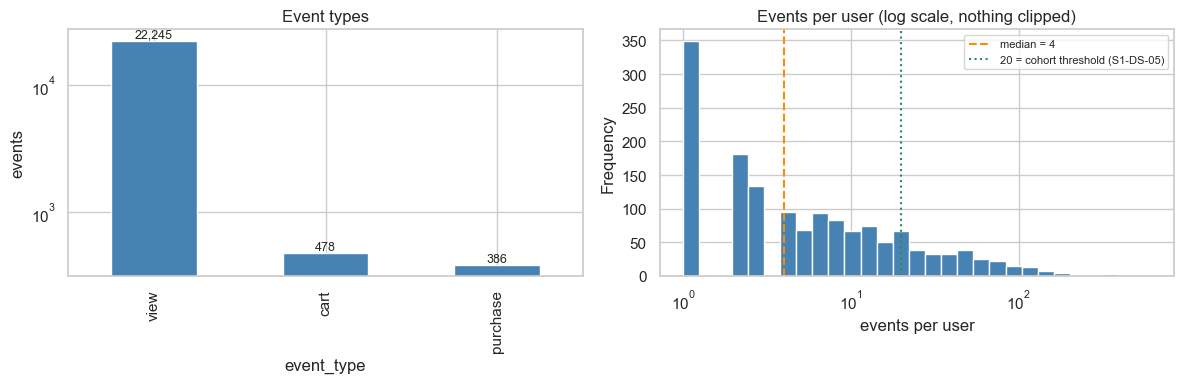

In [12]:
events_per_user = smoke.groupby("user_id").size()

print("Events per user in the smoke sample:")
print(events_per_user.describe().round(1))
print(f"\nUsers with 20+ events (long enough to model): "
      f"{(events_per_user >= 20).sum():,} of {len(events_per_user):,}")

figure, axes = plt.subplots(1, 2, figsize=(12, 4))

# Views outnumber the rest ~50 to 1, so a linear axis hides cart and purchase.
# The counts are printed on the bars instead of guessing from bar height.
counts = smoke["event_type"].value_counts()
counts.plot(kind="bar", ax=axes[0], color="steelblue", title="Event types")
axes[0].set_ylabel("events")
axes[0].set_yscale("log")
for position, value in enumerate(counts):
    axes[0].text(position, value, f"{value:,}", ha="center", va="bottom", fontsize=9)

# The tail runs from 1 to 611 events, so the x axis is log scaled with log bins.
# Nothing is clipped: piling every heavy user into an edge bin would invent a
# spike at the cut-off that does not exist in the data.
bins = np.logspace(0, np.log10(events_per_user.max()), 30)
events_per_user.plot(kind="hist", bins=bins, ax=axes[1], color="steelblue",
                     title="Events per user (log scale, nothing clipped)")
axes[1].set_xscale("log")
axes[1].set_xlabel("events per user")
axes[1].axvline(events_per_user.median(), color="darkorange", linestyle="--",
                label=f"median = {events_per_user.median():.0f}")
axes[1].axvline(20, color="seagreen", linestyle=":",
                label="20 = cohort threshold (S1-DS-05)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

### What this fixture is — and what it is not

The smoke fixture preserves the natural long-tail client-size distribution: 1,499 users ranging
from 1 to 611 events, median 4. That skew is deliberate and matches the full dataset.

It is intended for **interface and integration testing**, not as the authoritative training
cohort. Cohort eligibility is defined downstream in `S1-DS-05` and `S1-DS-06`.

**For the federated lane specifically:** use these 1,499 users to exercise partitioning and
client heterogeneity, but do not treat them as eligible scientific FL clients — only 281 of
them have 20 or more events. The real eligible pool comes later from the `CohortManifest`.

## 6. Does the fixture actually contain the hard cases?

A fixture that only holds easy rows gives false confidence. Rather than shipping a separate
hand-written file, we check the real sample directly and report what it covers.

Anything marked `NO` is a genuine gap: that path is untested here and the lane that needs it
must supply its own test data.

In [13]:
# A fixture is only useful if it really contains the hard cases, so we check
# instead of assuming. Anything reported as NO is a gap the downstream lane has
# to cover with its own test data.
funnels = (smoke.groupby(["user_id", "item_id"])["event_type"]
           .agg(lambda types: {"view", "cart", "purchase"}.issubset(set(types))).sum())
events_by_user = smoke.groupby("user_id").size()
ordered = smoke.sort_values(["user_id", "event_time"])
gaps = ordered.groupby("user_id")["event_time"].diff().dt.total_seconds()
timestamp_ties = smoke.groupby(["user_id", "event_time"]).size()

coverage = pd.DataFrame([
    ("full funnel view -> cart -> purchase", int(funnels)),
    ("users with a single event",            int((events_by_user == 1).sum())),
    ("brand replaced with __UNK__",          int((smoke["brand"] == UNKNOWN).sum())),
    ("category_code replaced with __UNK__",  int((smoke["category_code"] == UNKNOWN).sum())),
    ("empty session_id",                     int(smoke["session_id"].isna().sum())),
    ("same user, identical timestamp",       int((timestamp_ties > 1).sum())),
    ("gap longer than 30 minutes",           int((gaps > 1800).sum())),
    ("user spanning 3+ categories",          int((smoke.groupby("user_id")["category_id"].nunique() >= 3).sum())),
    ("price of zero",                        int((smoke["price"] == 0).sum())),
], columns=["edge case", "rows"])
coverage["present"] = coverage["rows"].gt(0).map({True: "yes", False: "NO"})

print(coverage.to_string(index=False))

uncovered = coverage.loc[coverage["rows"] == 0, "edge case"].tolist()
if uncovered:
    print(f"\nNot present: {uncovered}")
    print("The full dataset holds only 2 rows with an empty session, so a 1-in-2000 user")
    print("sample is very unlikely to catch one. Session policy is owned by S1-DS-05, and")
    print("RetailRocket has no session column at all - that lane must test the empty-session")
    print("path with its own data.")

                           edge case  rows present
full funnel view -> cart -> purchase   141     yes
           users with a single event   349     yes
         brand replaced with __UNK__  3208     yes
 category_code replaced with __UNK__  6855     yes
                    empty session_id     0      NO
      same user, identical timestamp    15     yes
          gap longer than 30 minutes  2559     yes
         user spanning 3+ categories   421     yes
                       price of zero    22     yes

Not present: ['empty session_id']
The full dataset holds only 2 rows with an empty session, so a 1-in-2000 user
sample is very unlikely to catch one. Session policy is owned by S1-DS-05, and
RetailRocket has no session column at all - that lane must test the empty-session
path with its own data.


## 7. Validation

This function is the **actual contract**. Anyone on the team can call it on any dataframe to
confirm the shape. It returns a list of problems instead of failing with an opaque error.

We also run it on two deliberately broken copies — a check that passes on broken data is a
check that does not work.

In [14]:
def validate(frame, name):
    """Check a dataframe against CanonicalEvent v1. Returns a list of problems."""
    problems = []

    if list(frame.columns) != list(CANONICAL_FIELDS):
        problems.append(f"columns do not match the contract: got {list(frame.columns)}")
        print(f"{name}: FAIL")
        for problem in problems:
            print(f"   - {problem}")
        return problems

    for column in NEVER_MISSING:
        empty = frame[column].isna().sum()
        if empty:
            problems.append(f"{column} has {empty} missing values")

    unexpected = set(frame["event_type"].dropna().unique()) - set(ALLOWED_EVENT_TYPES)
    if unexpected:
        problems.append(f"unexpected event types: {sorted(unexpected)}")

    repeats = frame["event_id"].duplicated().sum()
    if repeats:
        problems.append(f"event_id is not unique ({repeats} repeats)")

    if not isinstance(frame["event_time"].dtype, pd.DatetimeTZDtype):
        problems.append(f"event_time is {frame['event_time'].dtype}, expected a UTC datetime")
    elif str(frame["event_time"].dt.tz) != "UTC":
        problems.append(f"event_time timezone is {frame['event_time'].dt.tz}, expected UTC")
    else:
        # Compare values, not index labels, so a filtered frame is judged fairly.
        keys = frame[ROW_ORDER].reset_index(drop=True)
        if not keys.equals(keys.sort_values(ROW_ORDER).reset_index(drop=True)):
            problems.append(f"rows are not ordered by {ROW_ORDER}")

    negative = (frame["price"] < 0).sum()
    if negative:
        problems.append(f"{negative} rows have a negative price")

    named = frame["session_id"].dropna()
    if len(named) and not named.str.startswith("rees46:session:").all():
        problems.append("some session_id values are not namespaced")

    print(f"{name}: {'PASS' if not problems else 'FAIL'}")
    for problem in problems:
        print(f"   - {problem}")
    return problems

In [15]:
smoke_problems = validate(smoke, "smoke_sample")

# Deliberately broken copies, to prove the check actually catches problems.
small = smoke.head(20).reset_index(drop=True)

bad_event = small.copy()
bad_event.loc[0, "event_type"] = "remove_from_cart"
bad_event_problems = validate(bad_event, "broken: invented event type")

bad_order = small.iloc[::-1].copy()
bad_order_problems = validate(bad_order, "broken: reversed order")

assert not smoke_problems, "the smoke sample must be valid"
assert bad_event_problems and bad_order_problems, "the validator must catch broken frames"
print()
print("All three checks behaved as expected.")

smoke_sample: PASS
broken: invented event type: FAIL
   - unexpected event types: ['remove_from_cart']
broken: reversed order: FAIL
   - rows are not ordered by ['event_time', 'source_row_number']

All three checks behaved as expected.


## 8. Save the outputs

In [16]:
smoke_path = OUTPUT_DIR / "smoke_sample.parquet"
smoke.to_parquet(smoke_path, index=False)

schema_document = {
    "schema_version": SCHEMA_VERSION,
    "dataset_id": DATASET_ID,
    "fields": CANONICAL_FIELDS,
    "allowed_event_types": ALLOWED_EVENT_TYPES,
    "missing_value_token": UNKNOWN,
    "nullable_fields": ["session_id", "price"],
    "row_order": ROW_ORDER,
    "id_namespaces": {
        "user_id": "rees46:user:<raw id>",
        "session_id": "rees46:session:<raw id>",
        "item_id": "rees46:item:<raw id>",
        "category_id": "rees46:category:<raw id>",
        "event_id": "rees46:2019-10:<raw csv row number>",
    },
    "fixture": {
        "smoke_sample.parquet": {
            "description": "every event of a deterministic slice of real users",
            "selection_rule": f"user_id % {USER_MODULUS} == {USER_REMAINDER}",
            "intended_use": "interface and integration testing, not a training cohort",
            "users": int(smoke["user_id"].nunique()),
            "events": int(len(smoke)),
            "users_with_20_plus_events": int((smoke.groupby("user_id").size() >= 20).sum()),
        },
    },
}

schema_path = OUTPUT_DIR / "canonical_event_v1.json"
schema_path.write_text(json.dumps(schema_document, indent=2, ensure_ascii=False), encoding="utf-8")

for path in [smoke_path, schema_path]:
    print(f"{path.name:28} {path.stat().st_size / 1024:8.1f} KB")

smoke_sample.parquet           1022.1 KB
canonical_event_v1.json           1.7 KB


## 9. Summary

In [17]:
summary = pd.DataFrame([
    ("Canonical fields defined",  len(CANONICAL_FIELDS)),
    ("Event types allowed",       len(ALLOWED_EVENT_TYPES)),
    ("Smoke sample - users",      smoke["user_id"].nunique()),
    ("Smoke sample - events",     len(smoke)),
    ("Users with 20+ events",     int((smoke.groupby("user_id").size() >= 20).sum())),
    ("Edge cases covered",        f"{int(coverage['rows'].gt(0).sum())} of {len(coverage)}"),
    ("Validation failures",       len(smoke_problems)),
], columns=["item", "value"])

print(summary.to_string(index=False))
print()
print(f"Schema version: {SCHEMA_VERSION}")
print("The fixture is saved and valid. Other lanes can start from it.")

                    item  value
Canonical fields defined     12
     Event types allowed      3
    Smoke sample - users   1499
   Smoke sample - events  23109
   Users with 20+ events    281
      Edge cases covered 8 of 9
     Validation failures      0

Schema version: CanonicalEvent/v1
The fixture is saved and valid. Other lanes can start from it.


## What this task hands over

| File | Consumer |
|---|---|
| `canonical_event_v1.json` | The whole team — the written contract |
| `smoke_sample.parquet` | `S1-PR-06` client partitioning · `S1-SE-05` item representation · `S1-SE-08` CI checks |
| `validate()` | Anyone confirming their data matches the contract |

## What this task deliberately does **not** decide

- Session policy → `S1-DS-05`
- Price bucketing → `S1-SE-06`
- Dense integer indexing of IDs → after the vocabulary is frozen
- Which users enter the research cohort → `S1-DS-05`